<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/An_EfficientNetB3_Based_Transfer_Learning_Framework_on_the_PAD_UFES_20_Dataset(1st)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Skin Cancer(PAD-UFES-20)"  # change path

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs[:10])
    print("Files:", files[:10])
    print("-"*50)

/content/drive/MyDrive/Skin Cancer(PAD-UFES-20)
Folders: ['imgs_part_3', 'imgs_part_2', 'imgs_part_1']
Files: ['metadata.csv']
--------------------------------------------------
/content/drive/MyDrive/Skin Cancer(PAD-UFES-20)/imgs_part_3
Folders: ['imgs_part_3']
Files: []
--------------------------------------------------
/content/drive/MyDrive/Skin Cancer(PAD-UFES-20)/imgs_part_3/imgs_part_3
Folders: []
Files: ['PAT_1128_497_29.png', 'PAT_1128_497_322.png', 'PAT_1119_472_513.png', 'PAT_1112_455_845.png', 'PAT_1113_458_387.png', 'PAT_1094_381_446.png', 'PAT_1102_408_613.png', 'PAT_1124_489_151.png', 'PAT_1132_508_325.png', 'PAT_1127_496_945.png']
--------------------------------------------------
/content/drive/MyDrive/Skin Cancer(PAD-UFES-20)/imgs_part_2
Folders: ['imgs_part_2']
Files: []
--------------------------------------------------
/content/drive/MyDrive/Skin Cancer(PAD-UFES-20)/imgs_part_2/imgs_part_2
Folders: []
Files: ['PAT_1013_82_876.png', 'PAT_1006_53_716.png', 'PAT_1008_

In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/Skin Cancer(PAD-UFES-20)/metadata.csv"

df = pd.read_csv(csv_path)

print(df.head())
print()
print(df.columns)

  patient_id  lesion_id  smoke  drink background_father background_mother  \
0   PAT_1516       1765    NaN    NaN               NaN               NaN   
1     PAT_46        881  False  False         POMERANIA         POMERANIA   
2   PAT_1545       1867    NaN    NaN               NaN               NaN   
3   PAT_1989       4061    NaN    NaN               NaN               NaN   
4    PAT_684       1302  False   True         POMERANIA         POMERANIA   

   age pesticide  gender skin_cancer_history  ... diameter_2 diagnostic  \
0    8       NaN     NaN                 NaN  ...        NaN        NEV   
1   55     False  FEMALE                True  ...        5.0        BCC   
2   77       NaN     NaN                 NaN  ...        NaN        ACK   
3   75       NaN     NaN                 NaN  ...        NaN        ACK   
4   79     False    MALE                True  ...        5.0        BCC   

    itch   grew   hurt  changed  bleed elevation                 img_id  \
0  FALSE  F

In [ ]:
print(df.columns)

Index(['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father',
       'background_mother', 'age', 'pesticide', 'gender',
       'skin_cancer_history', 'cancer_history', 'has_piped_water',
       'has_sewage_system', 'fitspatrick', 'region', 'diameter_1',
       'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed',
       'elevation', 'img_id', 'biopsed'],
      dtype='object')


In [ ]:
print(df.head())

  patient_id  lesion_id  smoke  drink background_father background_mother  \
0   PAT_1516       1765    NaN    NaN               NaN               NaN   
1     PAT_46        881  False  False         POMERANIA         POMERANIA   
2   PAT_1545       1867    NaN    NaN               NaN               NaN   
3   PAT_1989       4061    NaN    NaN               NaN               NaN   
4    PAT_684       1302  False   True         POMERANIA         POMERANIA   

   age pesticide  gender skin_cancer_history  ... diameter_2 diagnostic  \
0    8       NaN     NaN                 NaN  ...        NaN        NEV   
1   55     False  FEMALE                True  ...        5.0        BCC   
2   77       NaN     NaN                 NaN  ...        NaN        ACK   
3   75       NaN     NaN                 NaN  ...        NaN        ACK   
4   79     False    MALE                True  ...        5.0        BCC   

    itch   grew   hurt  changed  bleed elevation                 img_id  \
0  FALSE  F

In [ ]:
print(df['diagnostic'].value_counts())

diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64


In [ ]:
print("Total samples:", len(df))
print("Number of classes:", df['diagnostic'].nunique())
print(df['diagnostic'].unique())

Total samples: 2298
Number of classes: 6
['NEV' 'BCC' 'ACK' 'SEK' 'SCC' 'MEL']


In [ ]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

# Dataset root
dataset_path = "/content/drive/MyDrive/Skin Cancer(PAD-UFES-20)"

# CSV
df = pd.read_csv(os.path.join(dataset_path, "metadata.csv"))

# Create image lookup dictionary
image_paths = {}

folders = [
    os.path.join(dataset_path, "imgs_part_1", "imgs_part_1"),
    os.path.join(dataset_path, "imgs_part_2", "imgs_part_2"),
    os.path.join(dataset_path, "imgs_part_3", "imgs_part_3")
]

for folder in folders:
    for file in os.listdir(folder):
        image_paths[file] = os.path.join(folder, file)

# Add image path column
df["image_path"] = df["img_id"].map(image_paths)

# Remove missing images if any
df = df.dropna(subset=["image_path"])

print("Total available images:", len(df))

# Stratified train-test split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["diagnostic"]
)

print("Train samples:", len(train_df))
print("Test samples:", len(test_df))

# Output folder
split_path = "/content/drive/MyDrive/SkinCancer_Split"

train_path = os.path.join(split_path, "train")
test_path = os.path.join(split_path, "test")

# Remove old split if exists
if os.path.exists(split_path):
    shutil.rmtree(split_path)

# Create class folders
classes = sorted(df["diagnostic"].unique())

for folder in [train_path, test_path]:
    for cls in classes:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

# Copy train images
for _, row in train_df.iterrows():
    shutil.copy(
        row["image_path"],
        os.path.join(train_path, row["diagnostic"], row["img_id"])
    )

# Copy test images
for _, row in test_df.iterrows():
    shutil.copy(
        row["image_path"],
        os.path.join(test_path, row["diagnostic"], row["img_id"])
    )

print("\nDone!")
print("Classes:", classes)

Total available images: 2298
Train samples: 1838
Test samples: 460

Done!
Classes: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [ ]:
train_path = "/content/drive/MyDrive/SkinCancer_Split/train"
test_path = "/content/drive/MyDrive/SkinCancer_Split/test"

In [ ]:
IMG_SIZE = 300
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 1838 images belonging to 6 classes.
Found 460 images belonging to 6 classes.
{'ACK': 0, 'BCC': 1, 'MEL': 2, 'NEV': 3, 'SCC': 4, 'SEK': 5}


In [ ]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

# Freeze all layers except last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=input_layer,
    outputs=output
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,706,421 (44.66 MB)

 Trainable params: 4,475,520 (17.07 MB)

 Non-trainable params: 7,230,901 (27.58 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5245433789954338), 1: np.float64(0.4531558185404339), 2: np.float64(7.2936507936507935), 3: np.float64(1.570940170940171), 4: np.float64(2.002178649237473), 5: np.float64(1.6294326241134751)}


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [

    EarlyStopping(
        patience=6,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        factor=0.3,
        patience=3
    ),

    ModelCheckpoint(
        "/content/drive/MyDrive/best_model_skin_cancer.h5",
        save_best_only=True
    )
]

In [17]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.2042 - loss: 2.3884 

58/58 ━━━━━━━━━━━━━━━━━━━━ 970s 16s/step - accuracy: 0.2350 - loss: 2.3135 - val_accuracy: 0.2391 - val_loss: 1.7658 - learning_rate: 1.0000e-04
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.3068 - loss: 1.8779 

58/58 ━━━━━━━━━━━━━━━━━━━━ 933s 16s/step - accuracy: 0.3177 - loss: 1.8321 - val_accuracy: 0.2500 - val_loss: 1.7062 - learning_rate: 1.0000e-04
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.3653 - loss: 1.6386 

58/58 ━━━━━━━━━━━━━━━━━━━━ 1023s 17s/step - accuracy: 0.3808 - loss: 1.6327 - val_accuracy: 0.2935 - val_loss: 1.6401 - learning_rate: 1.0000e-04
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.4238 - loss: 1.4910 

58/58 ━━━━━━━━━━━━━━━━━━━━ 922s 16s/step - accuracy: 0.4287 - loss: 1.4743 - val_accuracy: 0.3674 - val_loss: 1.5826 - learning_rate: 1.0000e-04
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.4480 - loss: 1.3909 

58/58 ━━━━━━━━━━━━━━━━━━━━ 910s 16s/step - accuracy: 0.4570 - loss: 1.3139 - val_accuracy: 0.4022 - val_loss: 1.4982 - learning_rate: 1.0000e-04
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 921s 16s/step - accuracy: 0.4918 - loss: 1.2555 - val_accuracy: 0.3957 - val_loss: 1.5202 - learning_rate: 1.0000e-04
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 904s 16s/step - accuracy: 0.5147 - loss: 1.2642 - val_accuracy: 0.4261 - val_loss: 1.5322 - learning_rate: 1.0000e-04
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 968s 17s/step - accuracy: 0.5408 - loss: 1.0631 - val_accuracy: 0.4457 - val_loss: 1.5308 - learning_rate: 1.0000e-04
Epoch 9/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 924s 16s/step - accuracy: 0.5501 - loss: 1.0710 - val_accuracy: 0.4717 - val_loss: 1.5055 - learning_rate: 3.0000e-05
Epoch 10/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.5370 - loss: 1.0169 

58/58 ━━━━━━━━━━━━━━━━━━━━ 988s 17s/step - accuracy: 0.5571 - loss: 0.9861 - val_accuracy: 0.4848 - val_loss: 1.4786 - learning_rate: 3.0000e-05


In [18]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", round(loss,4))
print("Test Accuracy :", round(accuracy*100,2), "%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 151s 10s/step - accuracy: 0.4848 - loss: 1.4786
Test Loss : 1.4786
Test Accuracy : 48.48 %


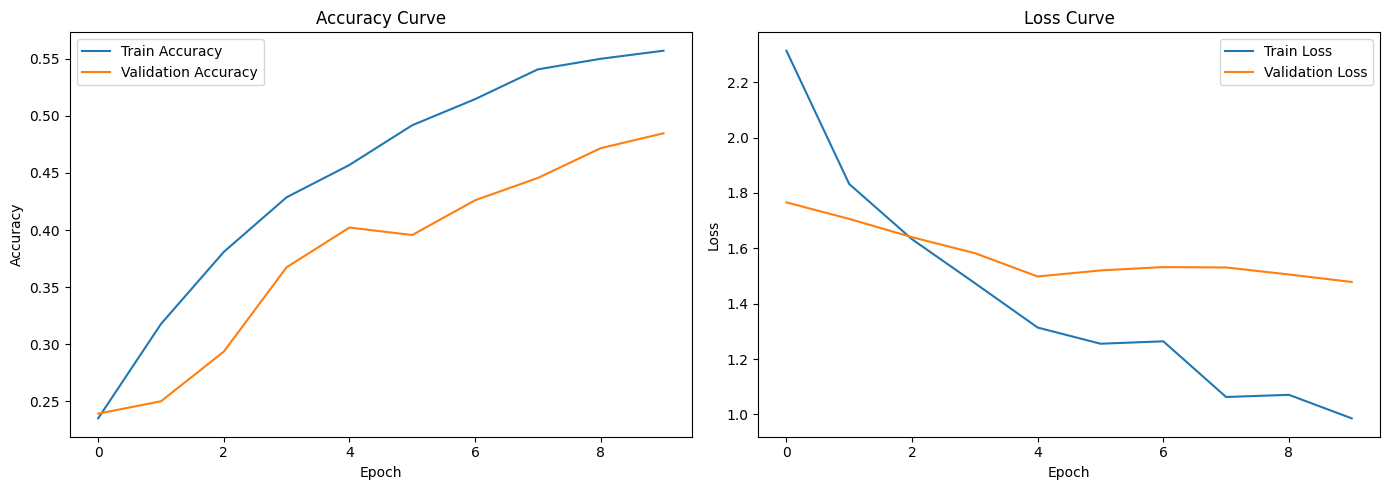

In [19]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(class_names)

15/15 ━━━━━━━━━━━━━━━━━━━━ 176s 11s/step
['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']


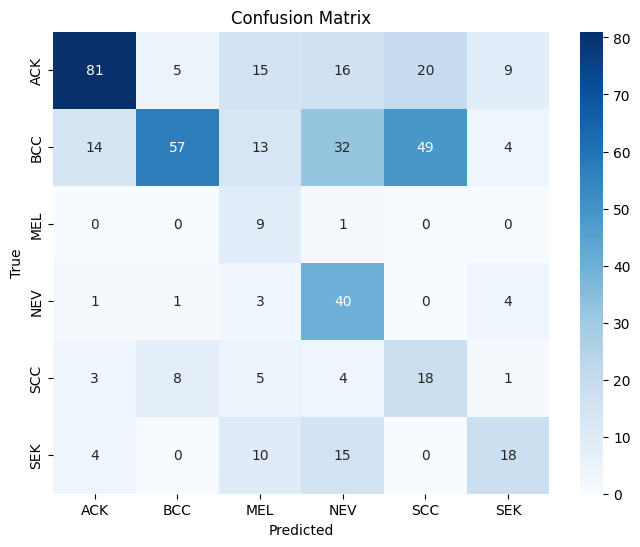

In [22]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [23]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

         ACK       0.79      0.55      0.65       146
         BCC       0.80      0.34      0.47       169
         MEL       0.16      0.90      0.28        10
         NEV       0.37      0.82      0.51        49
         SCC       0.21      0.46      0.29        39
         SEK       0.50      0.38      0.43        47

    accuracy                           0.48       460
   macro avg       0.47      0.58      0.44       460
weighted avg       0.66      0.48      0.51       460



In [24]:
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision :", round(precision*100,2), "%")
print("Recall    :", round(recall*100,2), "%")
print("F1 Score  :", round(f1*100,2), "%")

Precision : 65.62 %
Recall    : 48.48 %
F1 Score  : 50.98 %


In [25]:
n_classes = len(class_names)

y_true_bin = label_binarize(
    y_true,
    classes=range(n_classes)
)

In [26]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

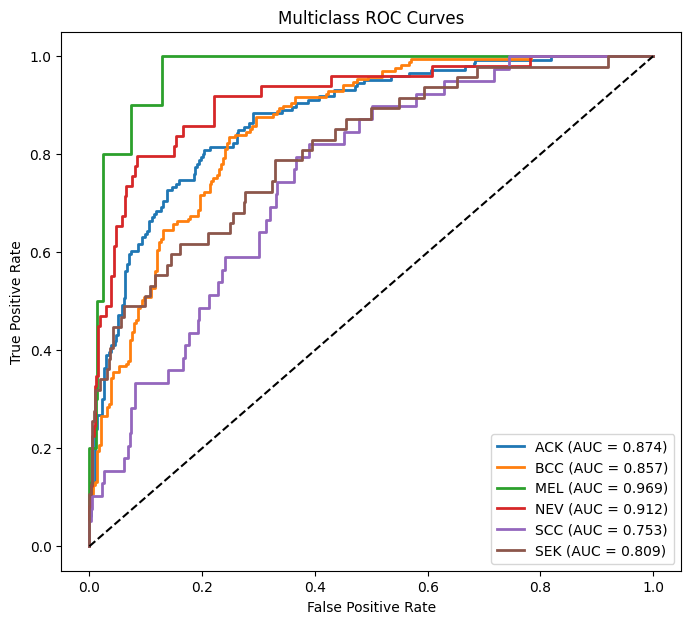

In [27]:
plt.figure(figsize=(8,7))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")

plt.legend()

plt.show()

In [28]:
print("\nAUC Values")

for i in range(n_classes):

    print(
        class_names[i],
        ":",
        round(roc_auc[i],4)
    )


AUC Values
ACK : 0.8744
BCC : 0.8569
MEL : 0.9687
NEV : 0.9123
SCC : 0.7529
SEK : 0.8095


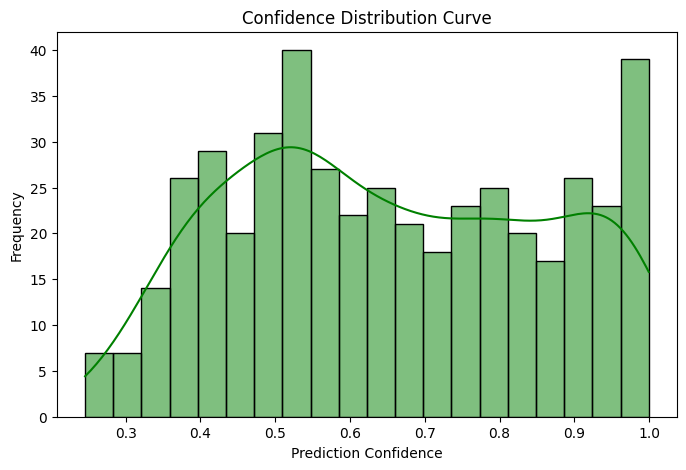

In [29]:
confidence_scores = np.max(
    y_pred_prob,
    axis=1
)

plt.figure(figsize=(8,5))

sns.histplot(
    confidence_scores,
    bins=20,
    kde=True,
    color='green'
)

plt.xlabel("Prediction Confidence")

plt.ylabel("Frequency")

plt.title("Confidence Distribution Curve")

plt.show()